
# Question 2: Flow Matching on FashionMNIST

This notebook guides you through the Flow Matching part of Assignment 3. You will train a model that learns a continuous velocity field from data to noise and then compare ODE-based generation with the DDPM baseline from Question 1.

Primary reference: [Flow Matching for Generative Modeling](https://arxiv.org/abs/2210.02747) by Lipman et al. (2023).

Edit this file before running the smoke test and training sections:
- `q2_flow_matching.py`

Provided support files:
- `q2_trainer_fm.py`
- `ddpm_utils/`
- `images/`
- `requirements.txt`

Recommended Colab workflow:
1. Download `assignment3_release.zip`, unzip it on your computer first, and upload the extracted `assignment3_release/` folder to Google Drive. Do not upload the zip file to Drive.
2. Open the notebook from that Drive folder, mount Drive, and run the setup cells below.
3. Complete the TODOs in `q2_flow_matching.py`.
4. Re-run the notebook from the top.



## Colab setup

Recommended workflow for Colab:
1. Download `assignment3_release.zip`, unzip it on your computer first, and upload the extracted `assignment3_release/` folder to Google Drive. Do not upload the zip file to Drive.
2. Open the notebook from Google Drive in Colab and mount Drive.
3. Run the next setup cell to locate the extracted release folder.
4. Finish the TODOs in `q2_flow_matching.py`.
5. Re-run the notebook from the top before training or comparing against DDPM.


In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

In [2]:

import os
import sys
from pathlib import Path


def _candidate_roots(cwd: Path):
    candidates = [
        Path('/content/drive/MyDrive/assignment3_release'),
        Path('/content/assignment3_release'),
        cwd,
    ]
    for parent in [cwd, *cwd.parents]:
        candidates.append(parent / 'assignment3_release')
    return candidates


def _is_project_root(path: Path, marker: str) -> bool:
    return path.is_dir() and (path / marker).exists()


def find_project_root(marker: str) -> Path:
    cwd = Path.cwd().resolve()
    seen_roots = set()
    for candidate in _candidate_roots(cwd):
        candidate = candidate.expanduser().resolve()
        if candidate in seen_roots:
            continue
        seen_roots.add(candidate)
        if _is_project_root(candidate, marker):
            return candidate

    raise FileNotFoundError(
        'Could not locate the Assignment 3 release folder. '
        'Unzip assignment3_release.zip on your computer first, upload the extracted assignment3_release folder to Google Drive, and do not upload the zip file itself. '
        'open the notebook from that folder, and rerun this cell.'
    )


PROJECT_ROOT = find_project_root('q2_flow_matching.py')
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')


Project root: C:\Users\guill\GitHub\IFT6135-Assignments\assignment-3


In [3]:
import importlib
import subprocess
import sys

for package in ["easydict"]:
    try:
        importlib.import_module(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])


## Imports and configuration

Q2 keeps the same FashionMNIST preprocessing and the same U-Net backbone as Q1. The main change is the learning objective and the ODE sampler used at generation time.

For the straight-line path used in this assignment, the key equations are:

$$x_t = (1-t)x_0 + t x_1, \quad t \in [0, 1]$$

$$u_t(x_1 \mid x_0) = x_1 - x_0$$

$$\mathcal{L}_{\text{FM}} = \mathbb{E}_{x_0, x_1, t}\left[\lVert v_\theta(x_t, t) - u_t(x_1 \mid x_0) \rVert_2^2\right]$$

$$\frac{d x_t}{dt} = v_\theta(x_t, t)$$


<img src="https://github.com/JingYue2000/HW_Supporting_materials/blob/main/flow_vs_diffusion.png?raw=true" width=500px>

*Figure: Flow Matching learns straight-line trajectories from noise to data via an ODE, while Diffusion models use a stochastic iterative denoising process.*


### Configuration

These defaults match the assignment setup and make the Q1 and Q2 comparisons easier to interpret.


In [4]:
import copy
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.utils.data

from ddpm_utils.args import args
from ddpm_utils.dataset import FashionMNISTDataset
from ddpm_utils.unet import UNet, load_weights
from q1_ddpm import DenoiseDiffusion
from q1_trainer_ddpm import Trainer as DDPMTrainer
from q2_flow_matching import FlowMatching
from q2_trainer_fm import Trainer as FlowTrainer

In [5]:
args.project_root = str(PROJECT_ROOT)
args.MODEL_PATH = str(PROJECT_ROOT / "q2_flow_matching_model.pkl")
args.flow_model_path = args.MODEL_PATH
args.device = "cuda" if torch.cuda.is_available() else "cpu"
args.fp16_precision = args.device == "cuda"
args.epochs = 20
args.batch_size = 256
args.learning_rate = 2e-4
args.n_samples = 16
args.image_size = 32
print(args)

{'image_channels': 1, 'image_size': 32, 'n_steps': 1000, 'nb_save': 5, 'batch_size': 256, 'n_samples': 16, 'learning_rate': 0.0002, 'epochs': 20, 'device': 'cuda', 'fp16_precision': True, 'show_every_n_epochs': 2, 'save_every_n_epochs': 2, 'num_workers': 0, 'project_root': 'C:\\Users\\guill\\GitHub\\IFT6135-Assignments\\assignment-3', 'ddpm_model_path': 'C:\\Users\\guill\\GitHub\\IFT6135-Assignments\\assignment-3\\q1_ddpm_model.pkl', 'flow_model_path': 'C:\\Users\\guill\\GitHub\\IFT6135-Assignments\\assignment-3\\q2_flow_matching_model.pkl', 'MODEL_PATH': 'C:\\Users\\guill\\GitHub\\IFT6135-Assignments\\assignment-3\\q2_flow_matching_model.pkl'}



## Student implementation checklist

Complete these functions in `q2_flow_matching.py` before running the smoke test or training cells:
- `sample_xt`
- `compute_conditional_velocity`
- `loss`
- `euler_step`
- `midpoint_step`

These TODOs correspond to the Flow Matching formulas above:
- `sample_xt`: implement the interpolation path $x_t = (1-t)x_0 + t x_1$.
- `compute_conditional_velocity`: return the straight-line target velocity $u_t(x_1 \mid x_0) = x_1 - x_0$.
- `loss`: fit $v_\theta(x_t, t)$ with the squared-error Flow Matching objective $\mathcal{L}_{\text{FM}}$.
- `euler_step`: integrate $\frac{dx_t}{dt} = v_\theta(x_t, t)$ with $x_{t+dt} = x_t + dt\,v_\theta(x_t, t)$.
- `midpoint_step`: use a second-order midpoint update with one evaluation at the start of the interval and one at the midpoint.

`q2_trainer_fm.py` is provided support code for training, sampling wrappers, and trajectory visualization. You do not need to modify it.


In [6]:
def plot_batch(batch, title, n_images=9):
    batch = batch.detach().cpu()[:n_images]
    cols = 3
    rows = 3
    fig, axes = plt.subplots(rows, cols, figsize=(8, 8))
    for ax, img in zip(axes.flatten(), batch):
        ax.imshow(img.squeeze(), cmap="gray")
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_comparison(rows, n_images=4):
    fig, axes = plt.subplots(len(rows), n_images, figsize=(3 * n_images, 3 * len(rows)))
    if len(rows) == 1:
        axes = axes[None, :]
    for row_idx, row in enumerate(rows):
        title = f"{row['method']} | steps={row['steps']} | NFE={row['nfe']} | {row['runtime_seconds']:.2f}s"
        for col_idx in range(n_images):
            axes[row_idx, col_idx].imshow(row['samples'][col_idx, 0], cmap="gray")
            axes[row_idx, col_idx].axis("off")
            if col_idx == 0:
                axes[row_idx, col_idx].set_ylabel(title, rotation=0, labelpad=80, fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_intermediate_trajectory(images, steps_to_show, n_samples):
    fig, axs = plt.subplots(n_samples, len(images), figsize=(3 * len(images), 3 * n_samples))
    if n_samples == 1:
        axs = axs[None, :]
    for sample_idx in range(n_samples):
        for step_idx, img in enumerate(images):
            axs[sample_idx, step_idx].imshow(img[sample_idx, 0], cmap="gray")
            title = "start noise" if step_idx == 0 else f"step {steps_to_show[step_idx - 1]}"
            axs[sample_idx, step_idx].set_title(title, fontsize=9)
            axs[sample_idx, step_idx].axis("off")
    plt.tight_layout()
    plt.show()


## Build the model and dataloader

This section prepares the shared U-Net backbone and the FashionMNIST dataloader. If you edit `q2_flow_matching.py`, rerun the import cells before continuing.


In [7]:
velocity_model = UNet(c_in=1, c_out=1)
if Path(args.MODEL_PATH).exists():
    velocity_model = load_weights(velocity_model, args.MODEL_PATH)

flow_matching = FlowMatching(velocity_model=velocity_model, device=args.device)
trainer = FlowTrainer(args, velocity_model, flow_matching)

dataloader = torch.utils.data.DataLoader(
    FashionMNISTDataset(root=str(PROJECT_ROOT)),
    batch_size=args.batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=args.num_workers,
    pin_memory=args.device == "cuda",
)
print(f"Using {args.device} with {len(dataloader)} batches per epoch.")

Using cuda with 234 batches per epoch.



## Smoke test

Before you launch training, finish `q2_flow_matching.py`, rerun the import cells, and then confirm that the loss executes on a small batch.


In [8]:
x0 = next(iter(dataloader))[:8].to(args.device)
loss = flow_matching.loss(x0, set_seed=True)
print(f"Smoke-test loss: {loss.item():.4f}")

Smoke-test loss: 2503.2456



## Train the Flow Matching model

Run this cell only after the TODOs are implemented and the smoke test succeeds. The trainer periodically saves sample grids for later comparison.



### FashionMNIST preview

Q1 and Q2 use the same FashionMNIST training data so the comparison focuses on the generative objective and the sampler rather than on the dataset or backbone. The next two cells show the preprocessed training tensors and the original labeled FashionMNIST images.


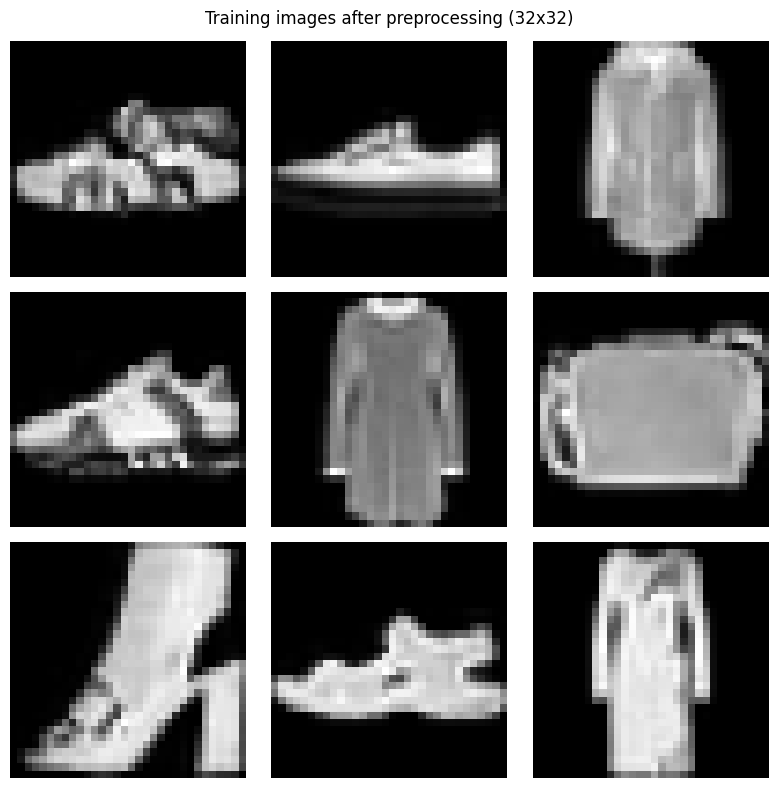

In [9]:
batch = next(iter(dataloader))[:9]

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for ax, img in zip(axes.flatten(), batch):
    ax.imshow(img.squeeze().cpu(), cmap="gray")
    ax.axis("off")

fig.suptitle(f"Training images after preprocessing ({args.image_size}x{args.image_size})")
plt.tight_layout()
plt.show()


100%|██████████| 26.4M/26.4M [00:01<00:00, 17.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 270kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.13MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]


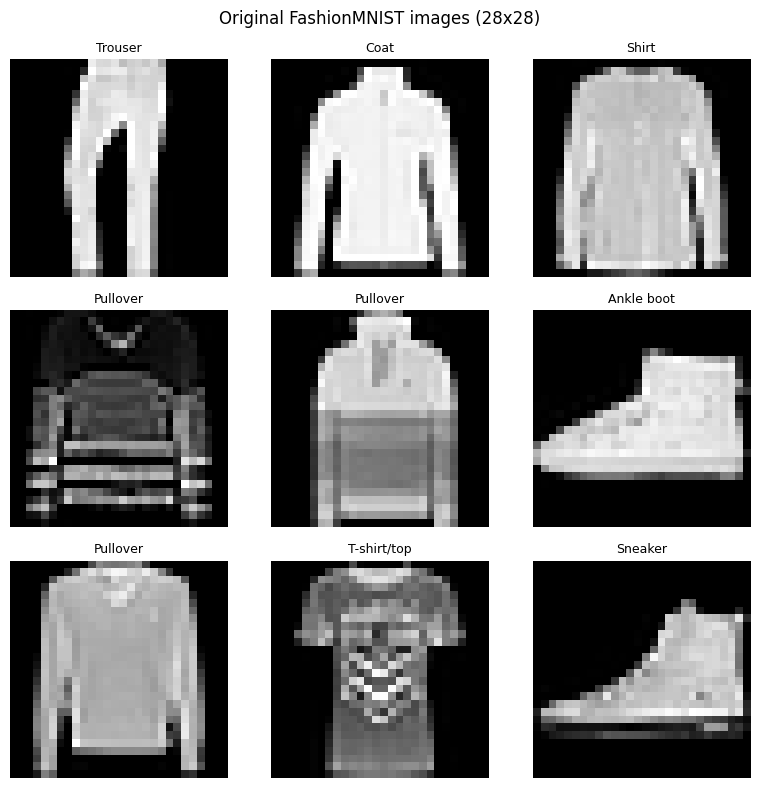

In [10]:
import torchvision

raw_dataset = torchvision.datasets.FashionMNIST(
    root=str(PROJECT_ROOT),
    train=True,
    download=True,
)

indices = torch.randperm(len(raw_dataset))[:9]

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for ax, idx in zip(axes.flatten(), indices):
    img, label = raw_dataset[idx.item()]
    ax.imshow(img, cmap="gray")
    ax.set_title(raw_dataset.classes[label], fontsize=9)
    ax.axis("off")

fig.suptitle("Original FashionMNIST images (28x28)")
plt.tight_layout()
plt.show()


Epoch: 0/20 - lr: 0.0002 - Loss: 374.39: 100%|██████████| 234/234 [01:01<00:00,  3.79it/s]


Showing/saving Flow Matching samples from epoch 0


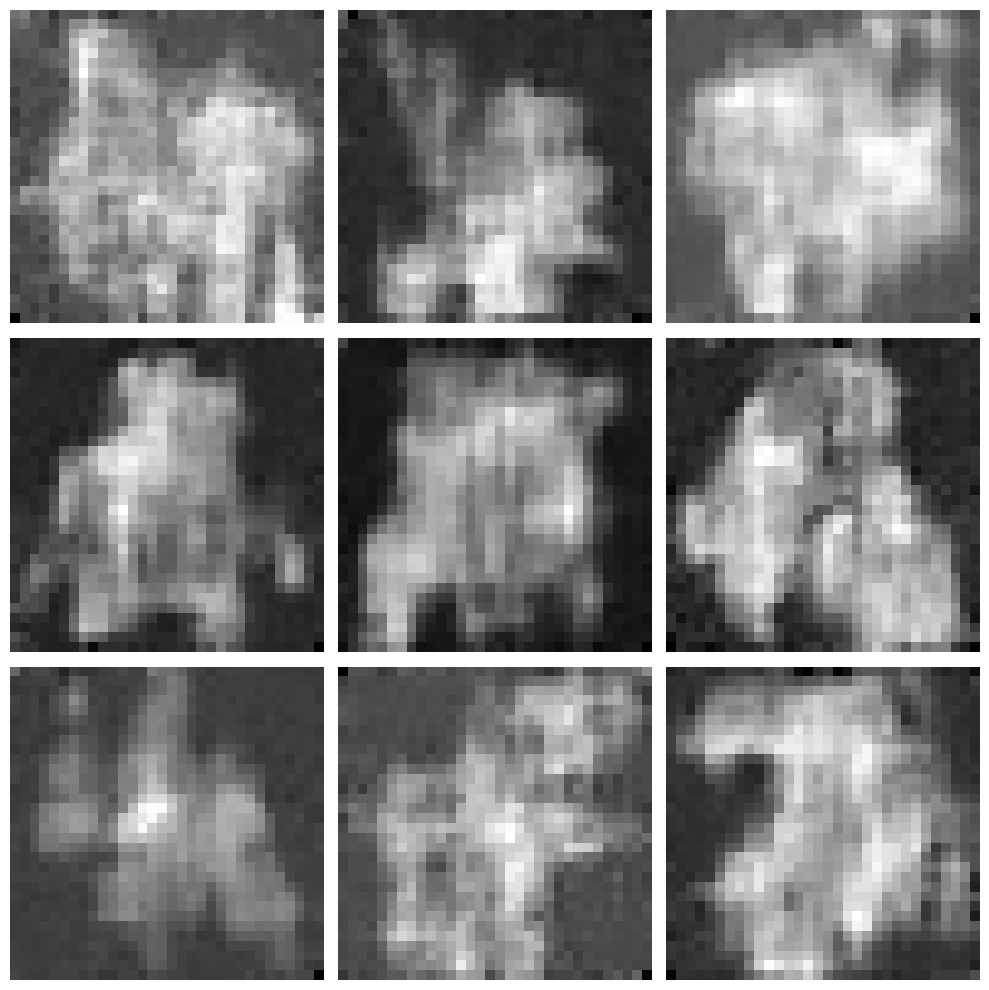

Epoch: 2/20 - lr: 0.0002 - Loss: 127.25: 100%|██████████| 234/234 [01:02<00:00,  3.74it/s]


Showing/saving Flow Matching samples from epoch 2


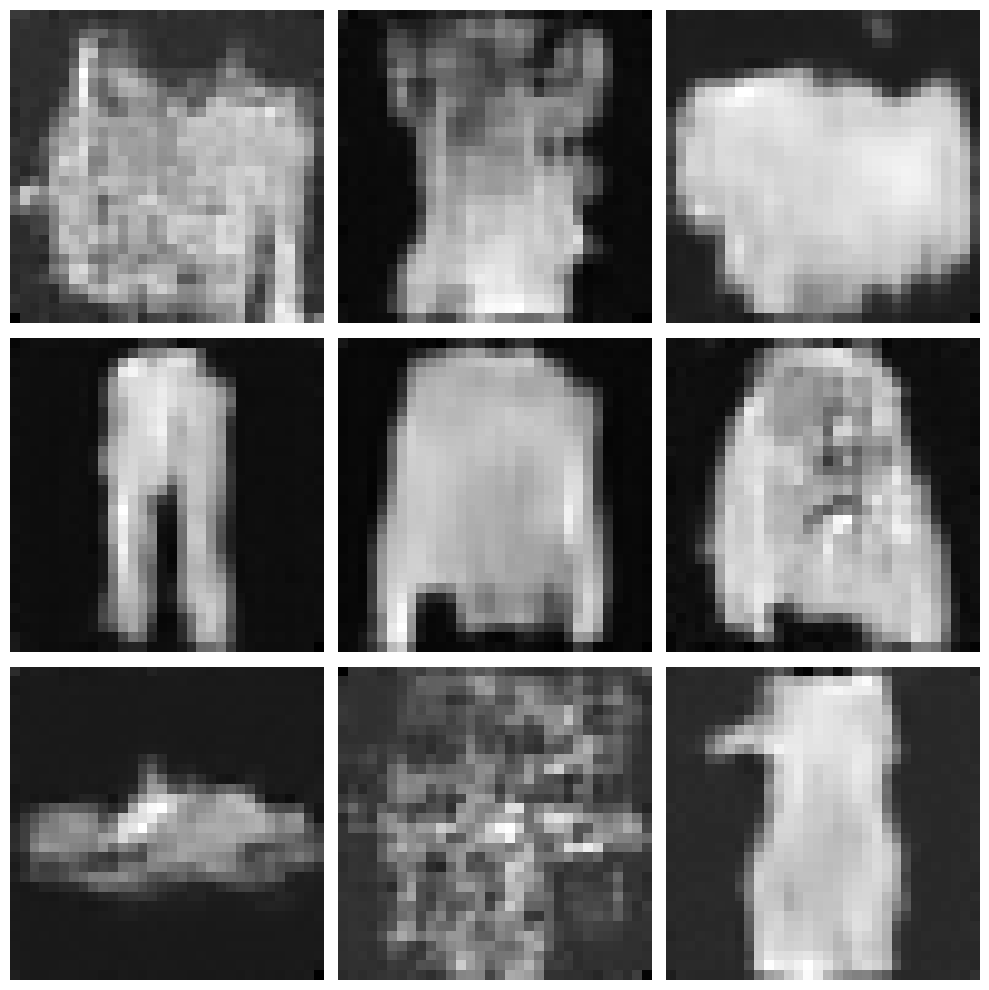

Epoch: 4/20 - lr: 0.0002 - Loss: 112.17: 100%|██████████| 234/234 [01:02<00:00,  3.72it/s]


Showing/saving Flow Matching samples from epoch 4


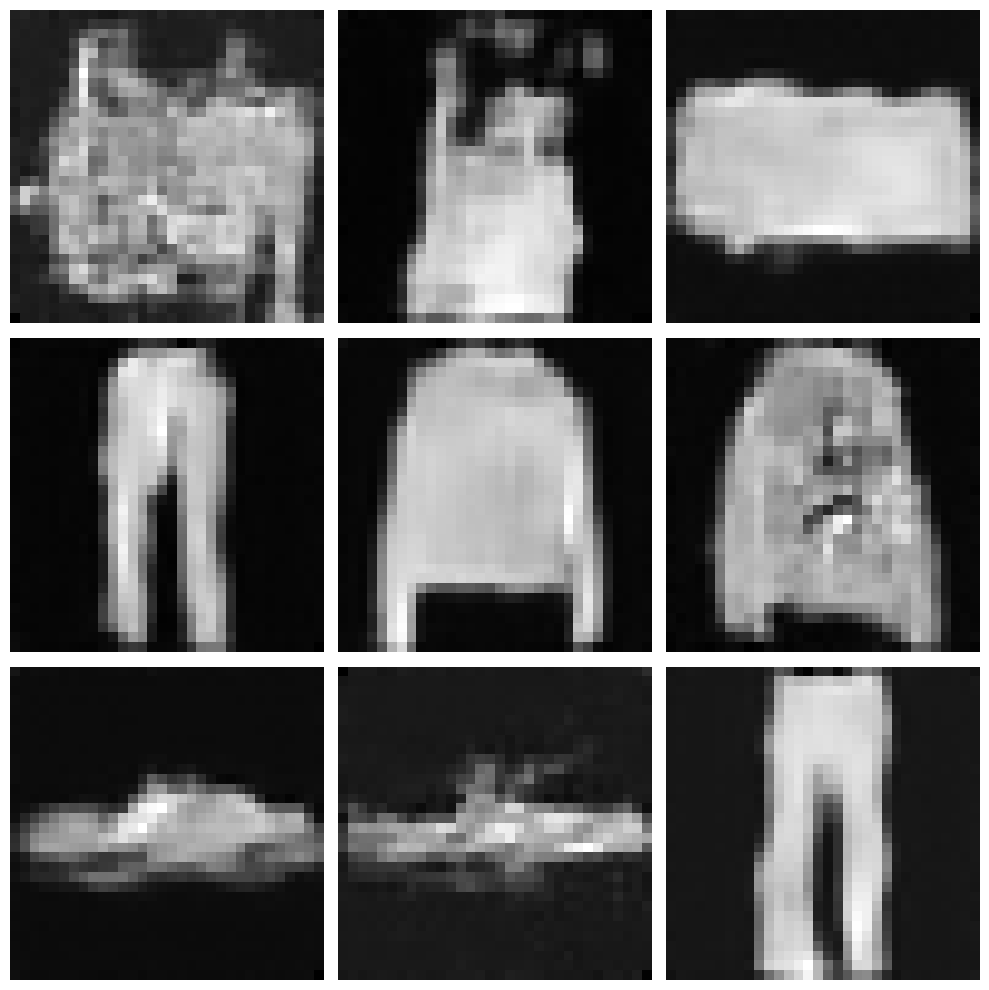

Epoch: 6/20 - lr: 0.0002 - Loss: 105.86: 100%|██████████| 234/234 [01:01<00:00,  3.79it/s]


Showing/saving Flow Matching samples from epoch 6


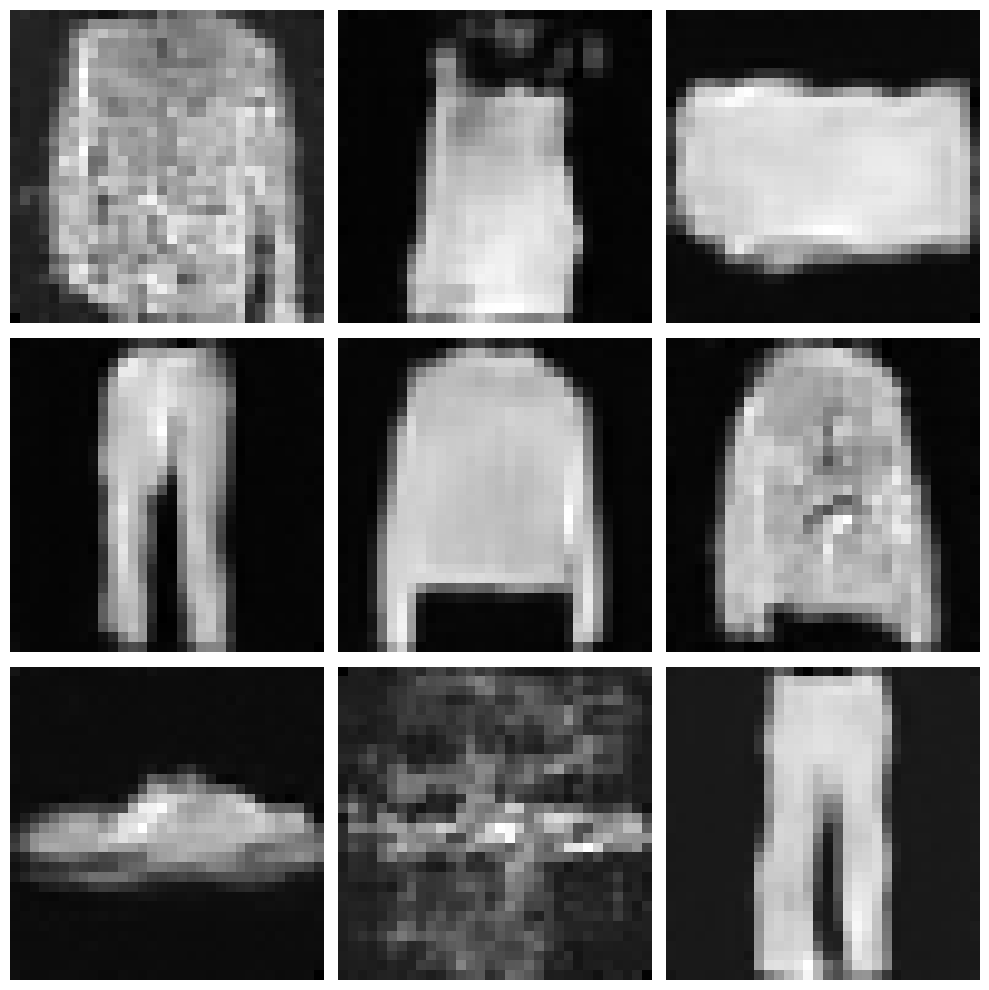

Epoch: 8/20 - lr: 0.0002 - Loss: 101.79: 100%|██████████| 234/234 [01:03<00:00,  3.66it/s]


Showing/saving Flow Matching samples from epoch 8


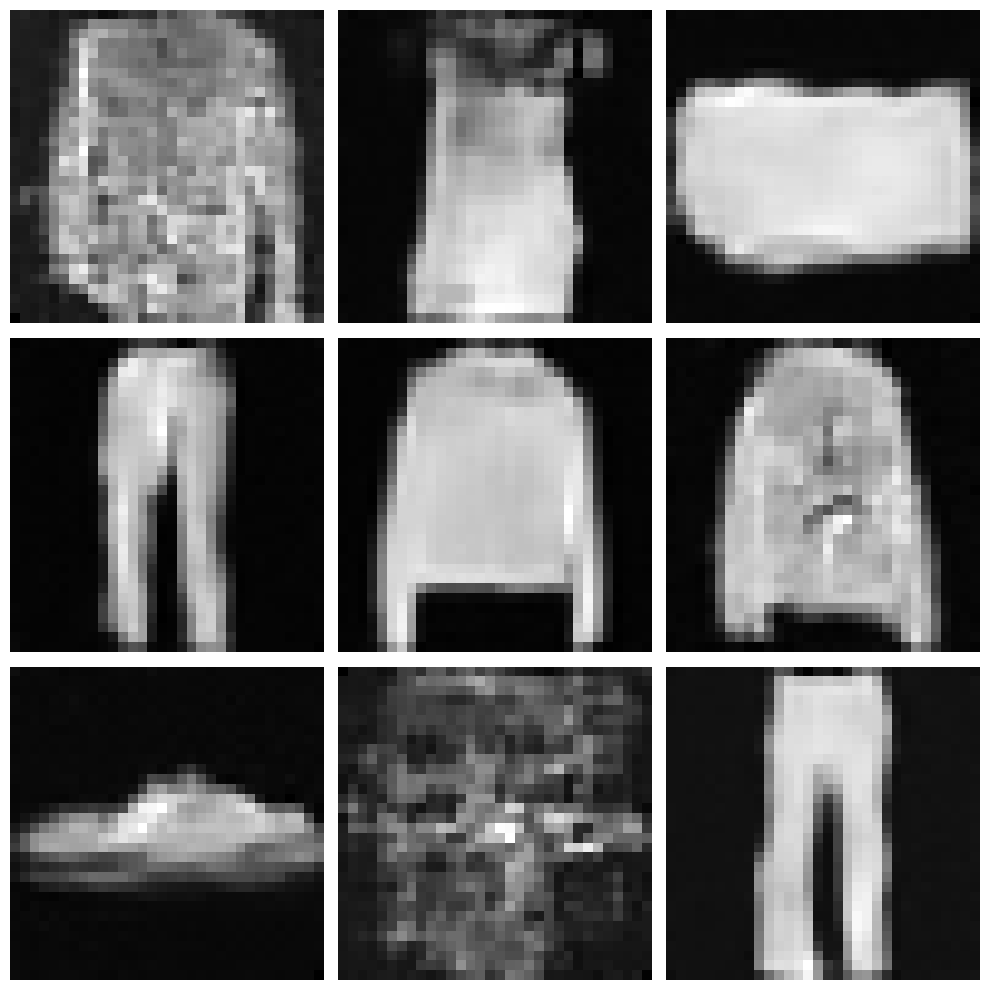

Epoch: 10/20 - lr: 2e-05 - Loss: 96.0: 100%|██████████| 234/234 [01:06<00:00,  3.53it/s] 


Showing/saving Flow Matching samples from epoch 10


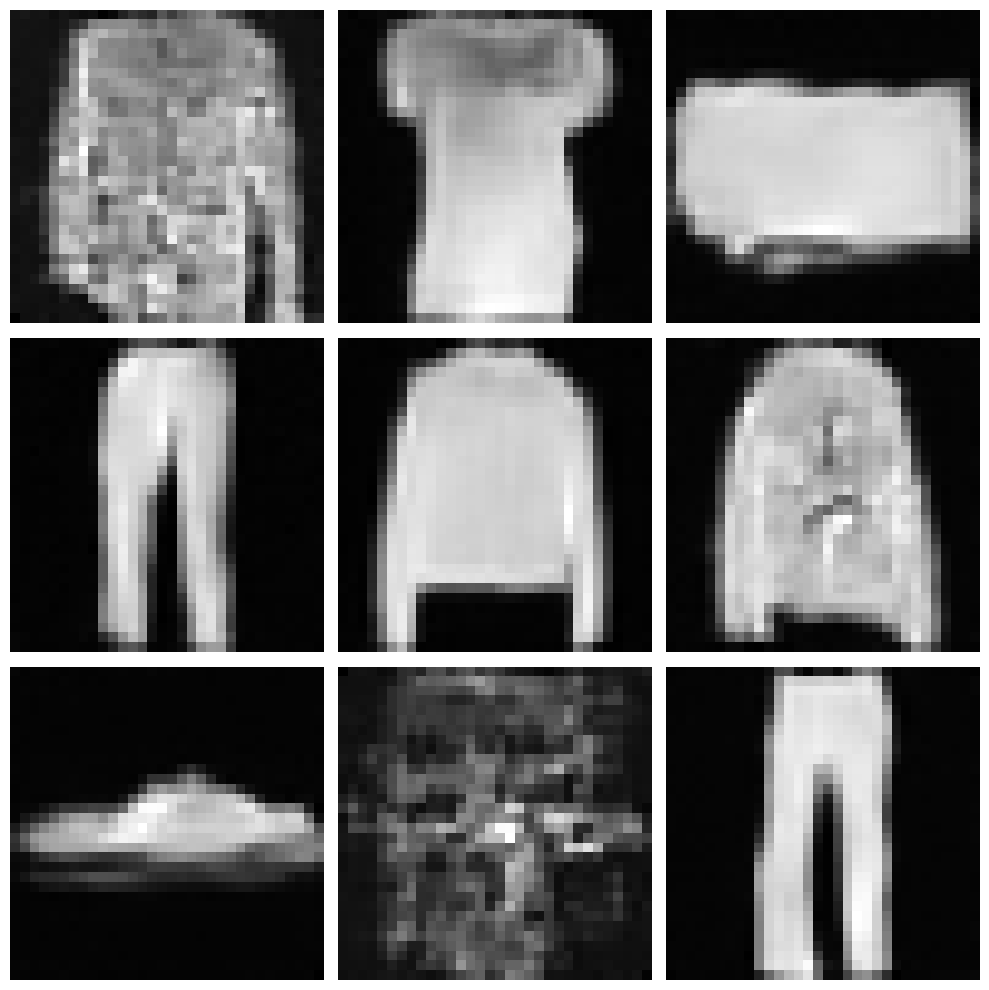

Epoch: 12/20 - lr: 2e-05 - Loss: 95.02: 100%|██████████| 234/234 [01:06<00:00,  3.52it/s]


Showing/saving Flow Matching samples from epoch 12


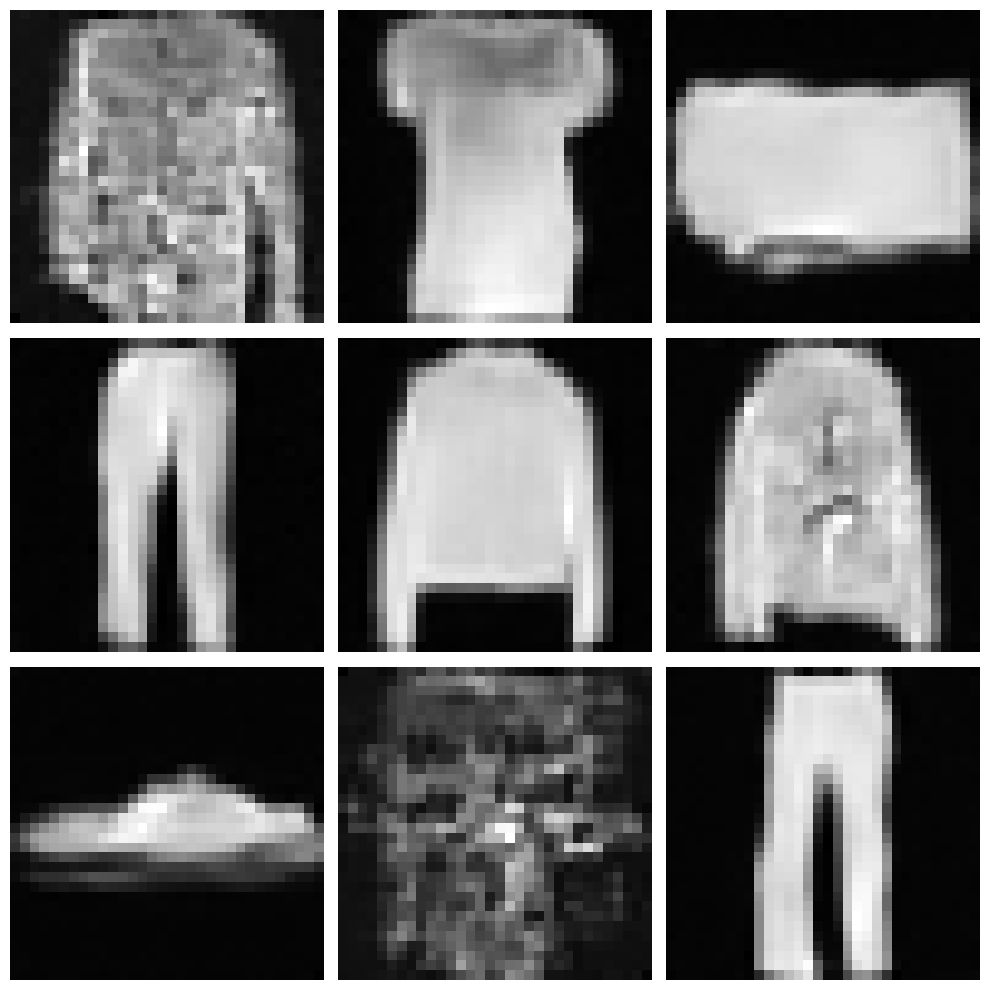

Epoch: 14/20 - lr: 2e-05 - Loss: 94.31: 100%|██████████| 234/234 [01:06<00:00,  3.51it/s]


Showing/saving Flow Matching samples from epoch 14


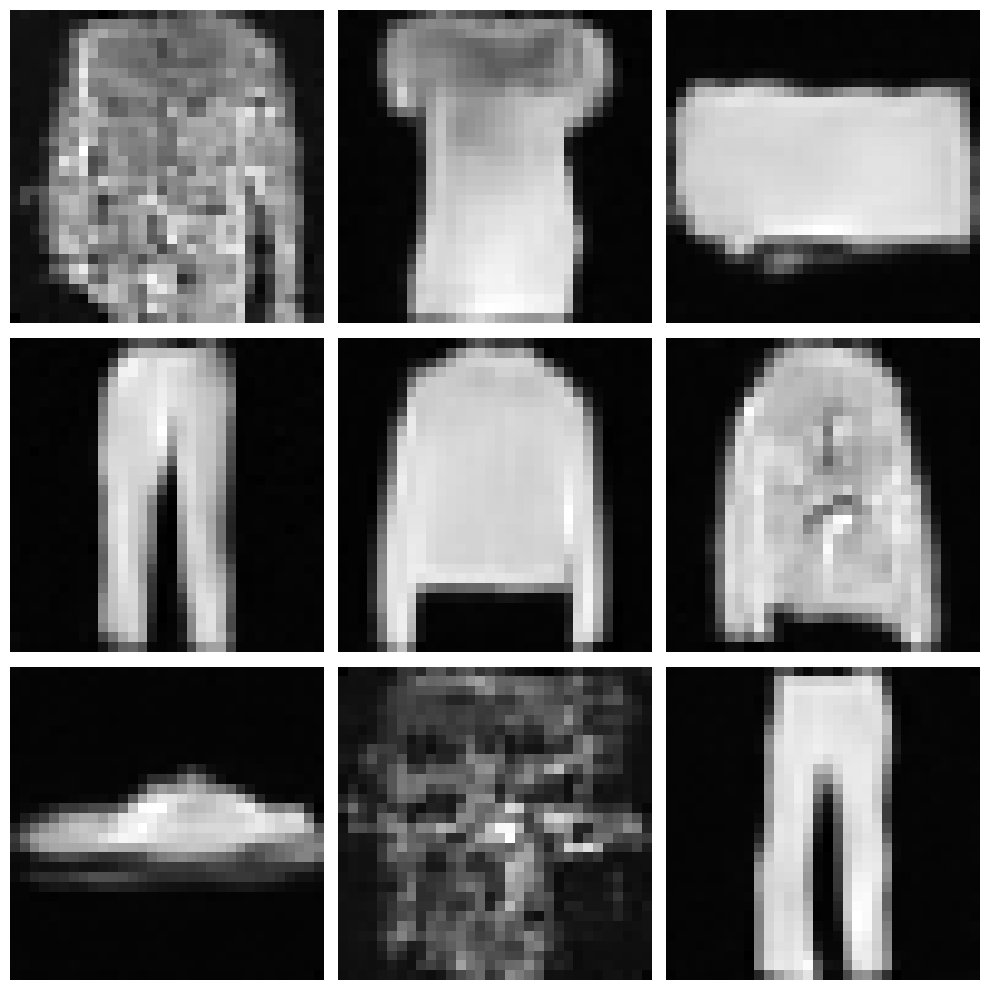

Epoch: 16/20 - lr: 2e-05 - Loss: 93.51: 100%|██████████| 234/234 [01:06<00:00,  3.51it/s]


Showing/saving Flow Matching samples from epoch 16


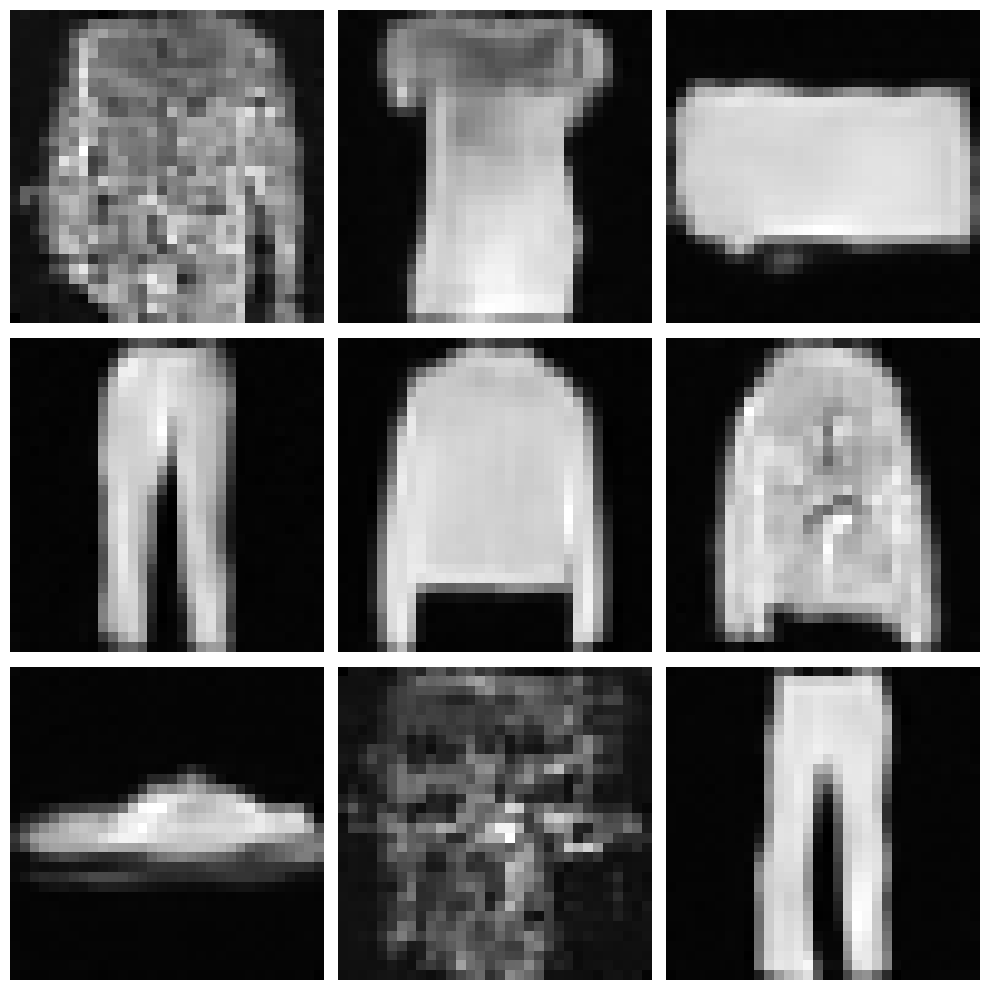

Epoch: 18/20 - lr: 2e-05 - Loss: 92.54: 100%|██████████| 234/234 [01:05<00:00,  3.55it/s]


Showing/saving Flow Matching samples from epoch 18


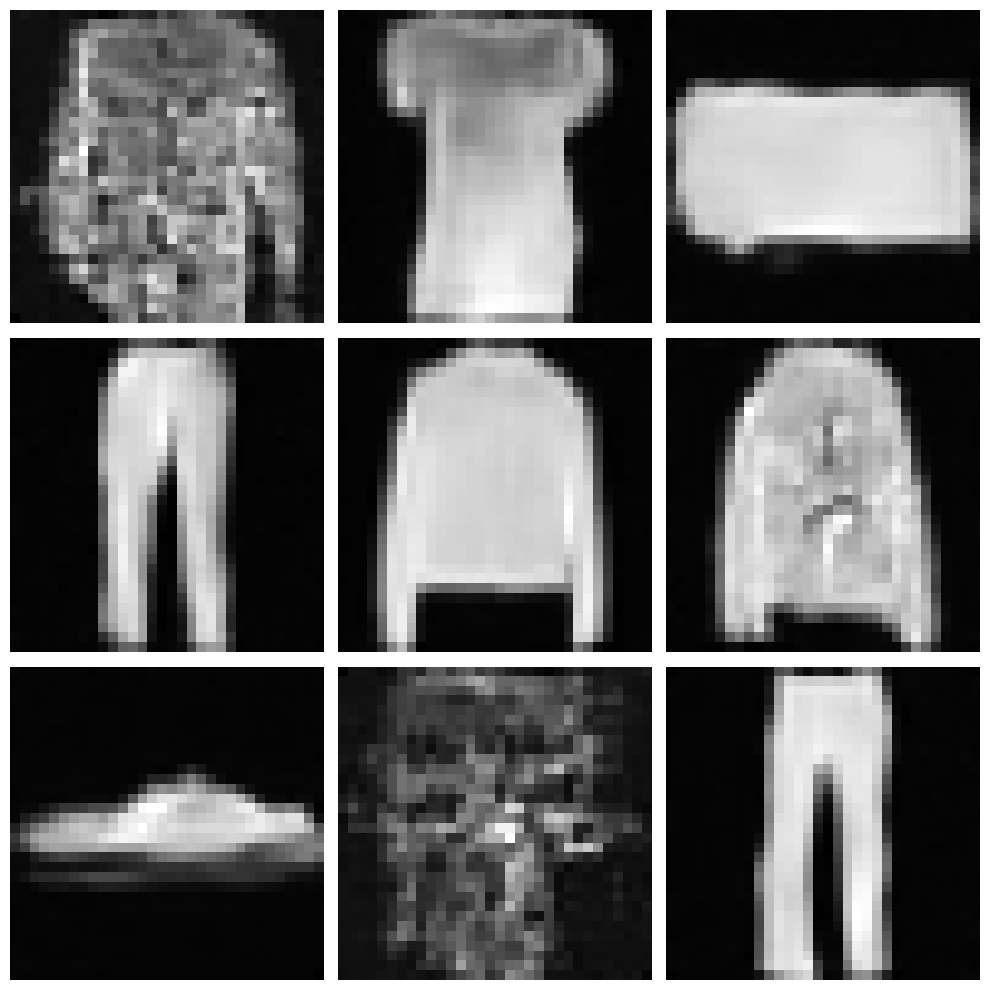

Epoch: 19/20 - lr: 2e-05 - Loss: 91.8: 100%|██████████| 234/234 [01:06<00:00,  3.50it/s] 


In [11]:
trainer.train(dataloader)
trainer.save_model()


## Report question 8: DDPM vs Flow Matching theory

Use the notebook results and the assignment equations to compare:
- the DDPM denoising objective versus the Flow Matching velocity objective
- stochastic reverse diffusion versus deterministic ODE integration
- how the same U-Net is used differently in Q1 and Q2



## Euler sampling at different step counts

This section shows how sample quality changes as you vary the number of Euler integration steps.


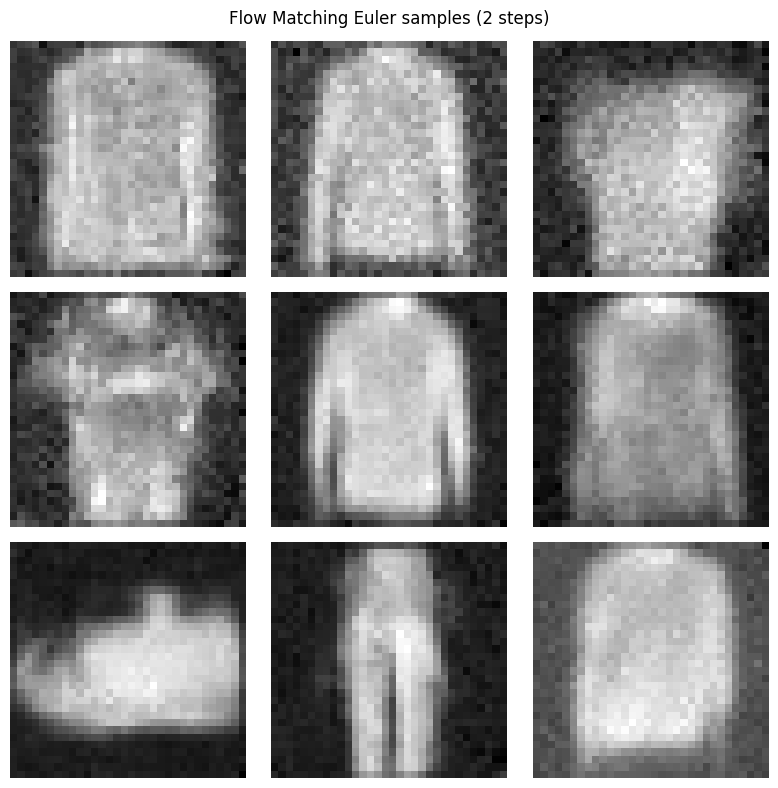

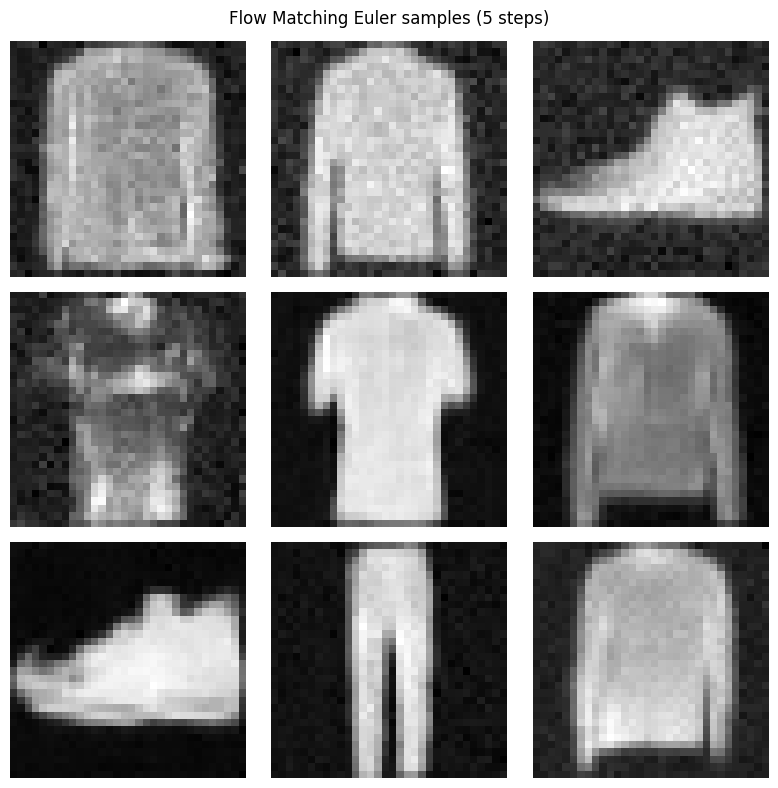

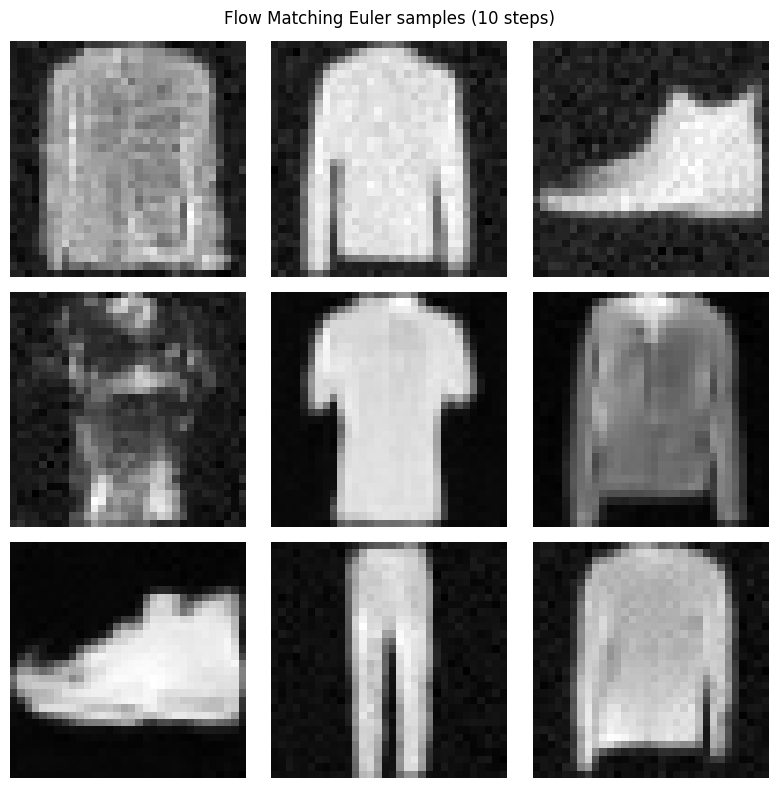

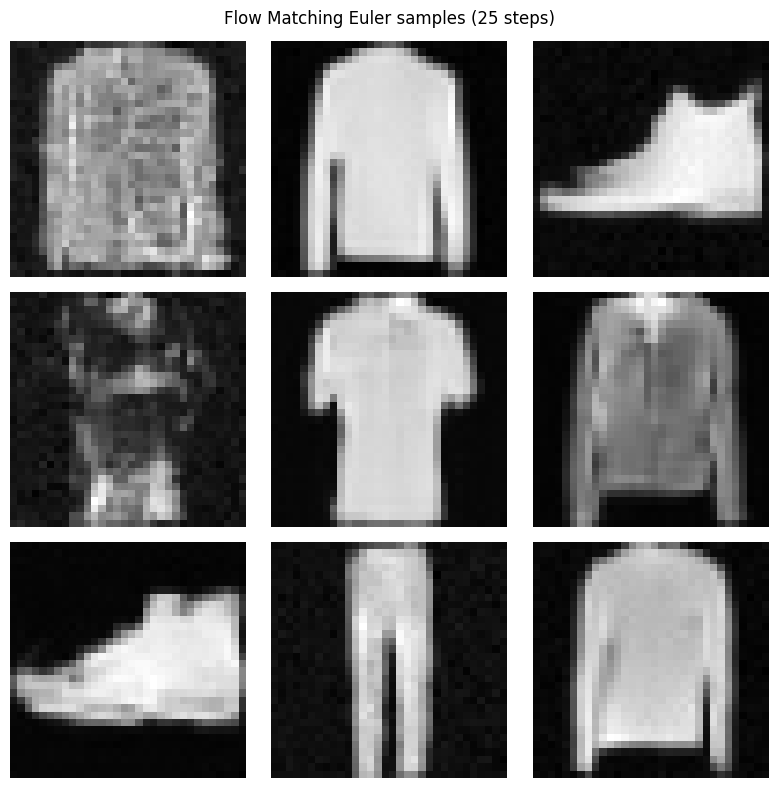

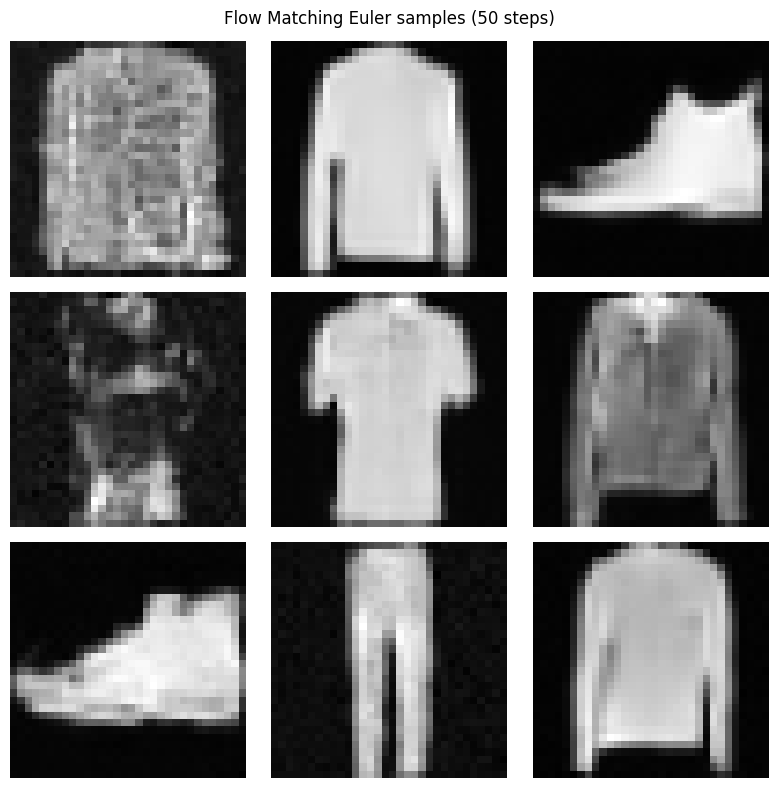

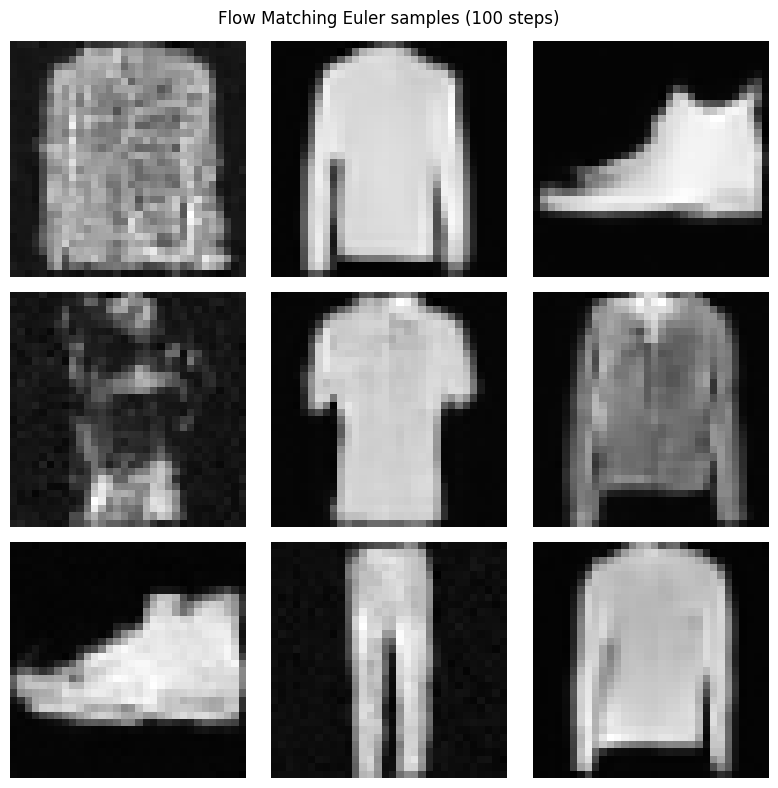

In [12]:
shared_noise = torch.randn(args.n_samples, 1, args.image_size, args.image_size, device=args.device)
for steps in [2, 5, 10, 25, 50, 100]:
    samples = trainer.sample(method="euler", n_steps=steps, noise=shared_noise.clone())
    plot_batch(samples, title=f"Flow Matching Euler samples ({steps} steps)")


## Midpoint sampling at different step counts

Midpoint uses two model evaluations per step. Compare its visual quality against Euler at similar or matched network-evaluation budgets.


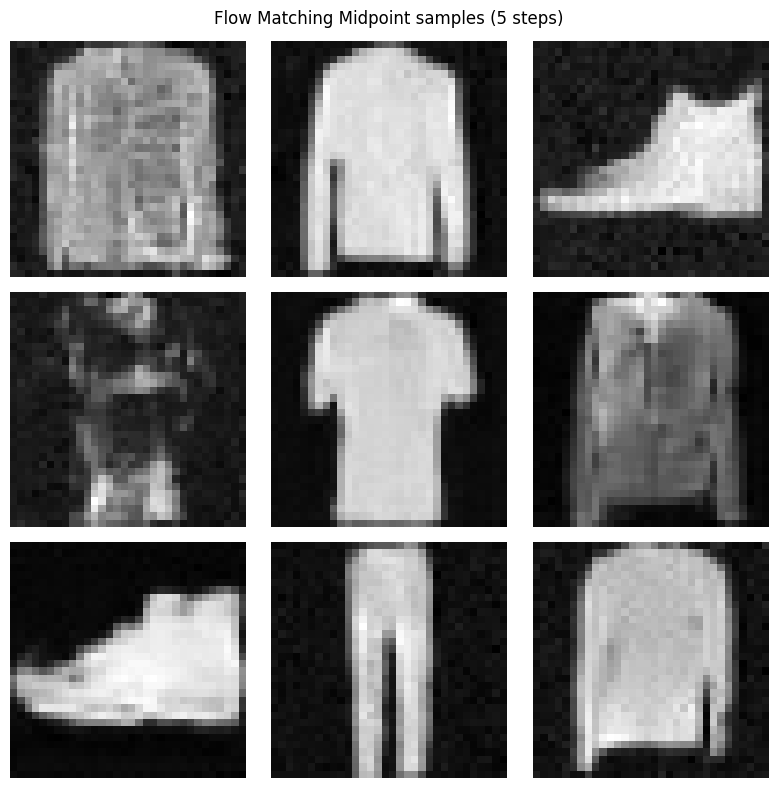

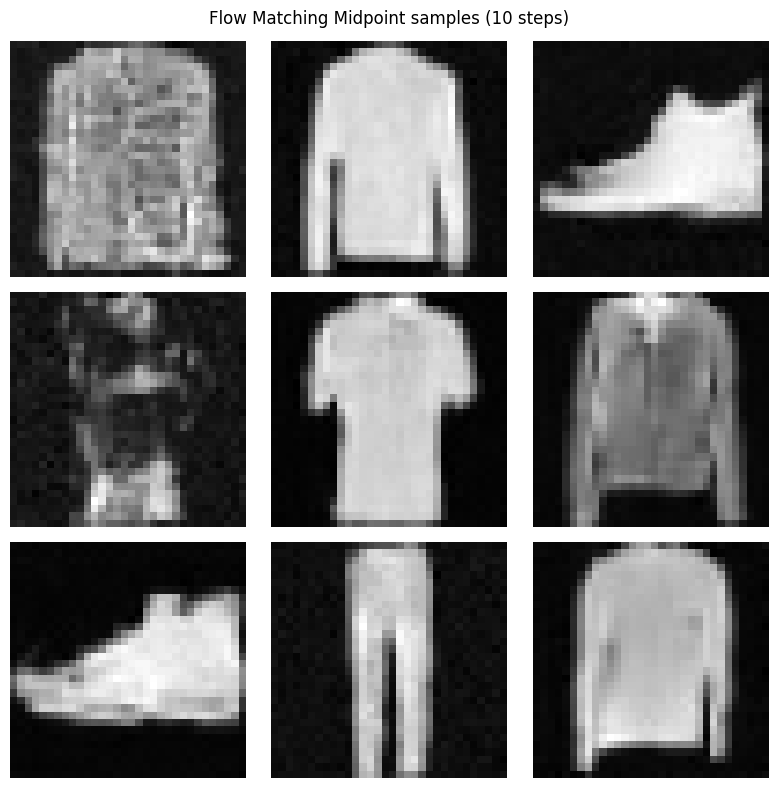

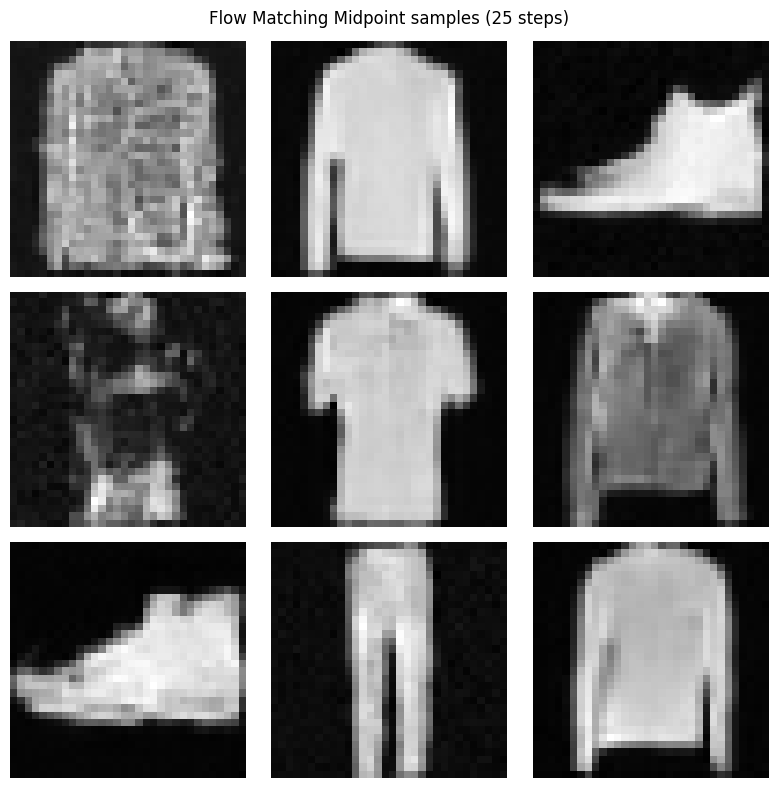

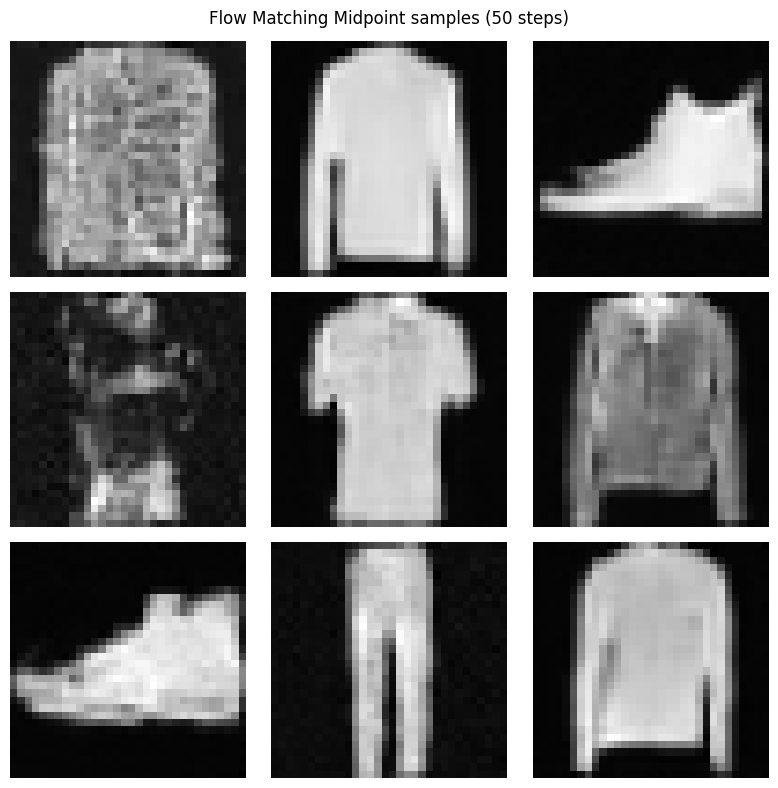

In [13]:
# Here we reuse the same starting noise across samplers for a fair comparison.
for steps in [5, 10, 25, 50]:
    samples = trainer.sample(method="midpoint", n_steps=steps, noise=shared_noise.clone())
    plot_batch(samples, title=f"Flow Matching Midpoint samples ({steps} steps)")



## DDPM vs Flow Matching comparison

Before running this section, make sure you have already completed Q1 and produced `q1_ddpm_model.pkl`. The goal here is to compare outputs starting from the same initial noise.


100%|█████████▉| 997/1000 [00:09<00:00, 97.62it/s] 

Showing/saving samples from epoch 0


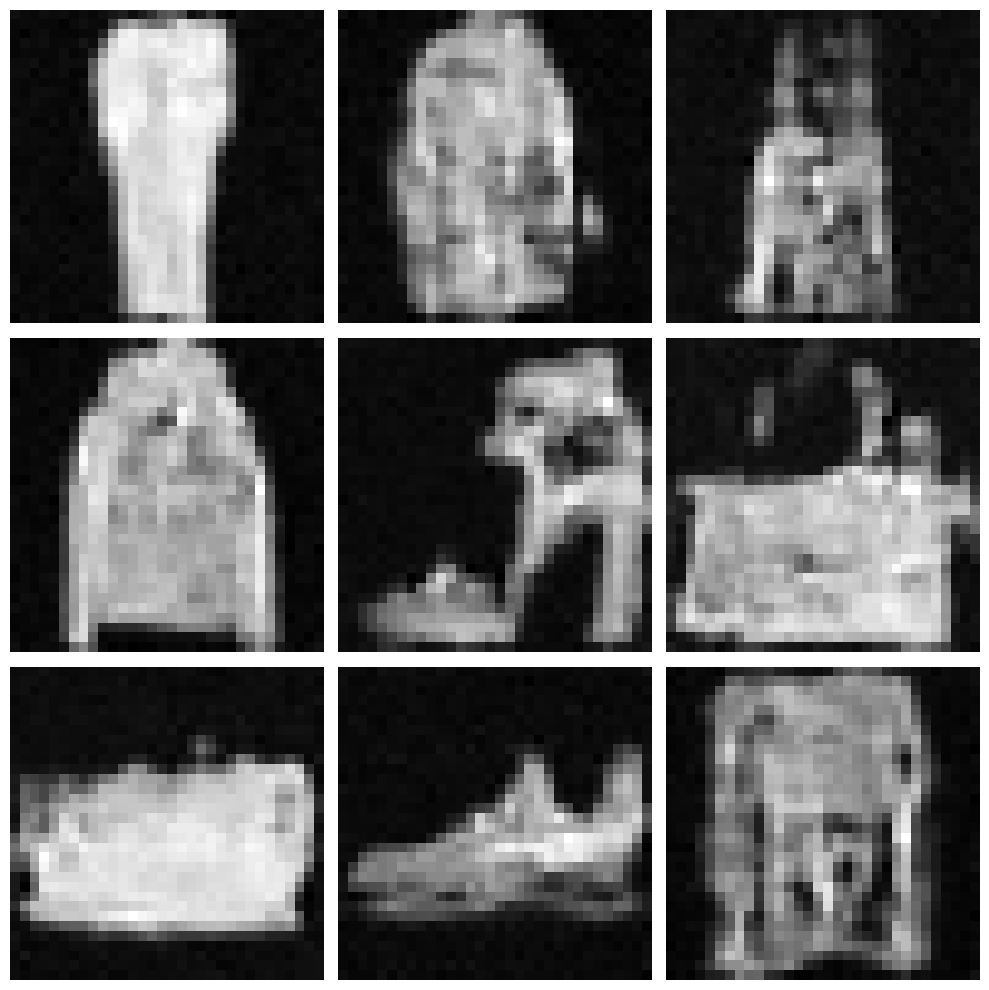

100%|██████████| 1000/1000 [00:10<00:00, 99.16it/s]


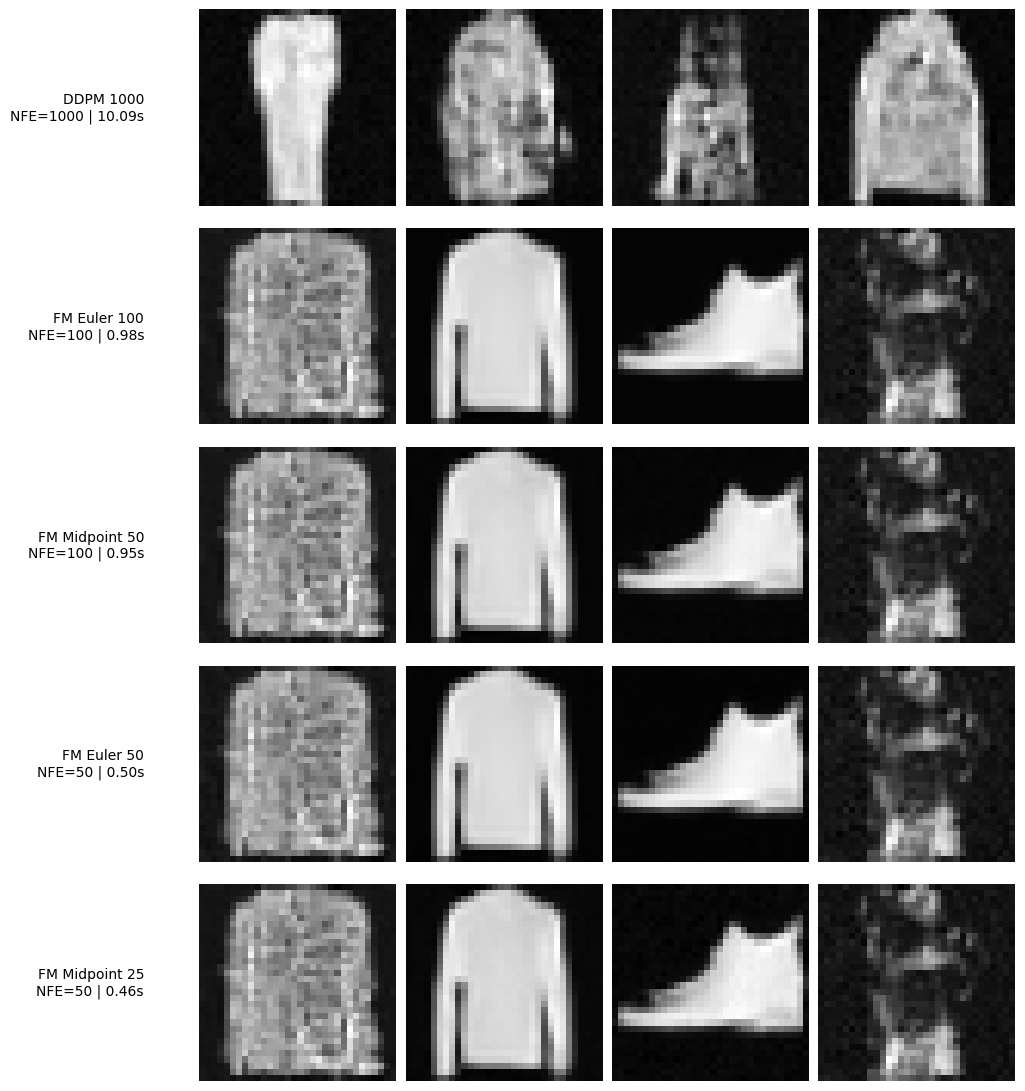

Label             | Steps | NFE  | Runtime
-------------------------------------------
DDPM 1000         |  1000 | 1000 | 10.09s
FM Euler 100      |   100 |  100 | 0.98s
FM Midpoint 50    |    50 |  100 | 0.95s
FM Euler 50       |    50 |   50 | 0.50s
FM Midpoint 25    |    25 |   50 | 0.46s


In [14]:
q1_model_path = PROJECT_ROOT / "q1_ddpm_model.pkl"
if not q1_model_path.exists():
    raise FileNotFoundError(
        "Run the DDPM notebook first so q1_ddpm_model.pkl exists for the comparison section."
    )

if "shared_noise" in globals() and tuple(shared_noise.shape) == (
    args.n_samples, 1, args.image_size, args.image_size
):
    comparison_noise = shared_noise.clone()
else:
    torch.manual_seed(42)
    comparison_noise = torch.randn(
        args.n_samples, 1, args.image_size, args.image_size, device=args.device
    )

ddpm_args = copy.deepcopy(args)
ddpm_args.MODEL_PATH = str(q1_model_path)
ddpm_args.n_steps = 1000

eps_model = UNet(c_in=1, c_out=1)
checkpoint = torch.load(q1_model_path, map_location=args.device)
eps_model.load_state_dict(checkpoint["model_state_dict"])
eps_model = eps_model.to(args.device).eval()

diffusion = DenoiseDiffusion(
    eps_model=eps_model,
    n_steps=ddpm_args.n_steps,
    device=ddpm_args.device,
)
ddpm_trainer = DDPMTrainer(ddpm_args, eps_model, diffusion)

def benchmark_ddpm(steps, noise):
    import time

    start_time = time.perf_counter()
    samples = ddpm_trainer.sample(n_steps=steps, noise=noise.clone(), set_seed=True)
    runtime_seconds = time.perf_counter() - start_time
    return {
        "method": "ddpm",
        "steps": steps,
        "nfe": steps,
        "runtime_seconds": runtime_seconds,
        "samples": samples.detach().cpu(),
        "label": f"DDPM {steps}",
    }

def plot_comparison_labeled(rows, n_images=4):
    fig, axes = plt.subplots(len(rows), n_images, figsize=(12, 2.8 * len(rows)))
    if len(rows) == 1:
        axes = axes[None, :]

    for row_idx, row in enumerate(rows):
        row_text = f"{row['label']}\nNFE={row['nfe']} | {row['runtime_seconds']:.2f}s"

        for col_idx in range(n_images):
            axes[row_idx, col_idx].imshow(
                row["samples"][col_idx, 0],
                cmap="gray",
                interpolation="nearest",
            )
            axes[row_idx, col_idx].axis("off")

        axes[row_idx, 0].text(
            -0.28, 0.5, row_text,
            transform=axes[row_idx, 0].transAxes,
            ha="right",
            va="center",
            fontsize=10,
        )

    plt.subplots_adjust(left=0.22, wspace=0.05, hspace=0.08)
    plt.show()


flow_rows = trainer.benchmark_sampling(
    [("euler", 100), ("midpoint", 50), ("euler", 50), ("midpoint", 25)],
    noise=comparison_noise.clone(),
    set_seed=True,
)

for row in flow_rows:
    if row["method"] == "euler":
        row["label"] = f"FM Euler {row['steps']}"
    else:
        row["label"] = f"FM Midpoint {row['steps']}"

ddpm_row = benchmark_ddpm(1000, comparison_noise)

comparison_rows = [
    ddpm_row,
    flow_rows[0],  # FM Euler 100
    flow_rows[1],  # FM Midpoint 50
    flow_rows[2],  # FM Euler 50
    flow_rows[3],  # FM Midpoint 25
]

plot_comparison_labeled(comparison_rows, n_images=4)

print("Label             | Steps | NFE  | Runtime")
print("-------------------------------------------")
for row in comparison_rows:
    print(
        f"{row['label']:<17s} | {row['steps']:>5d} | {row['nfe']:>4d} | {row['runtime_seconds']:.2f}s"
    )



## Flow trajectory visualization

This section shows the intermediate states of the learned ODE path, which complements the reverse-denoising trajectory you studied in Q1.


100%|██████████| 50/50 [00:00<00:00, 68.47it/s]


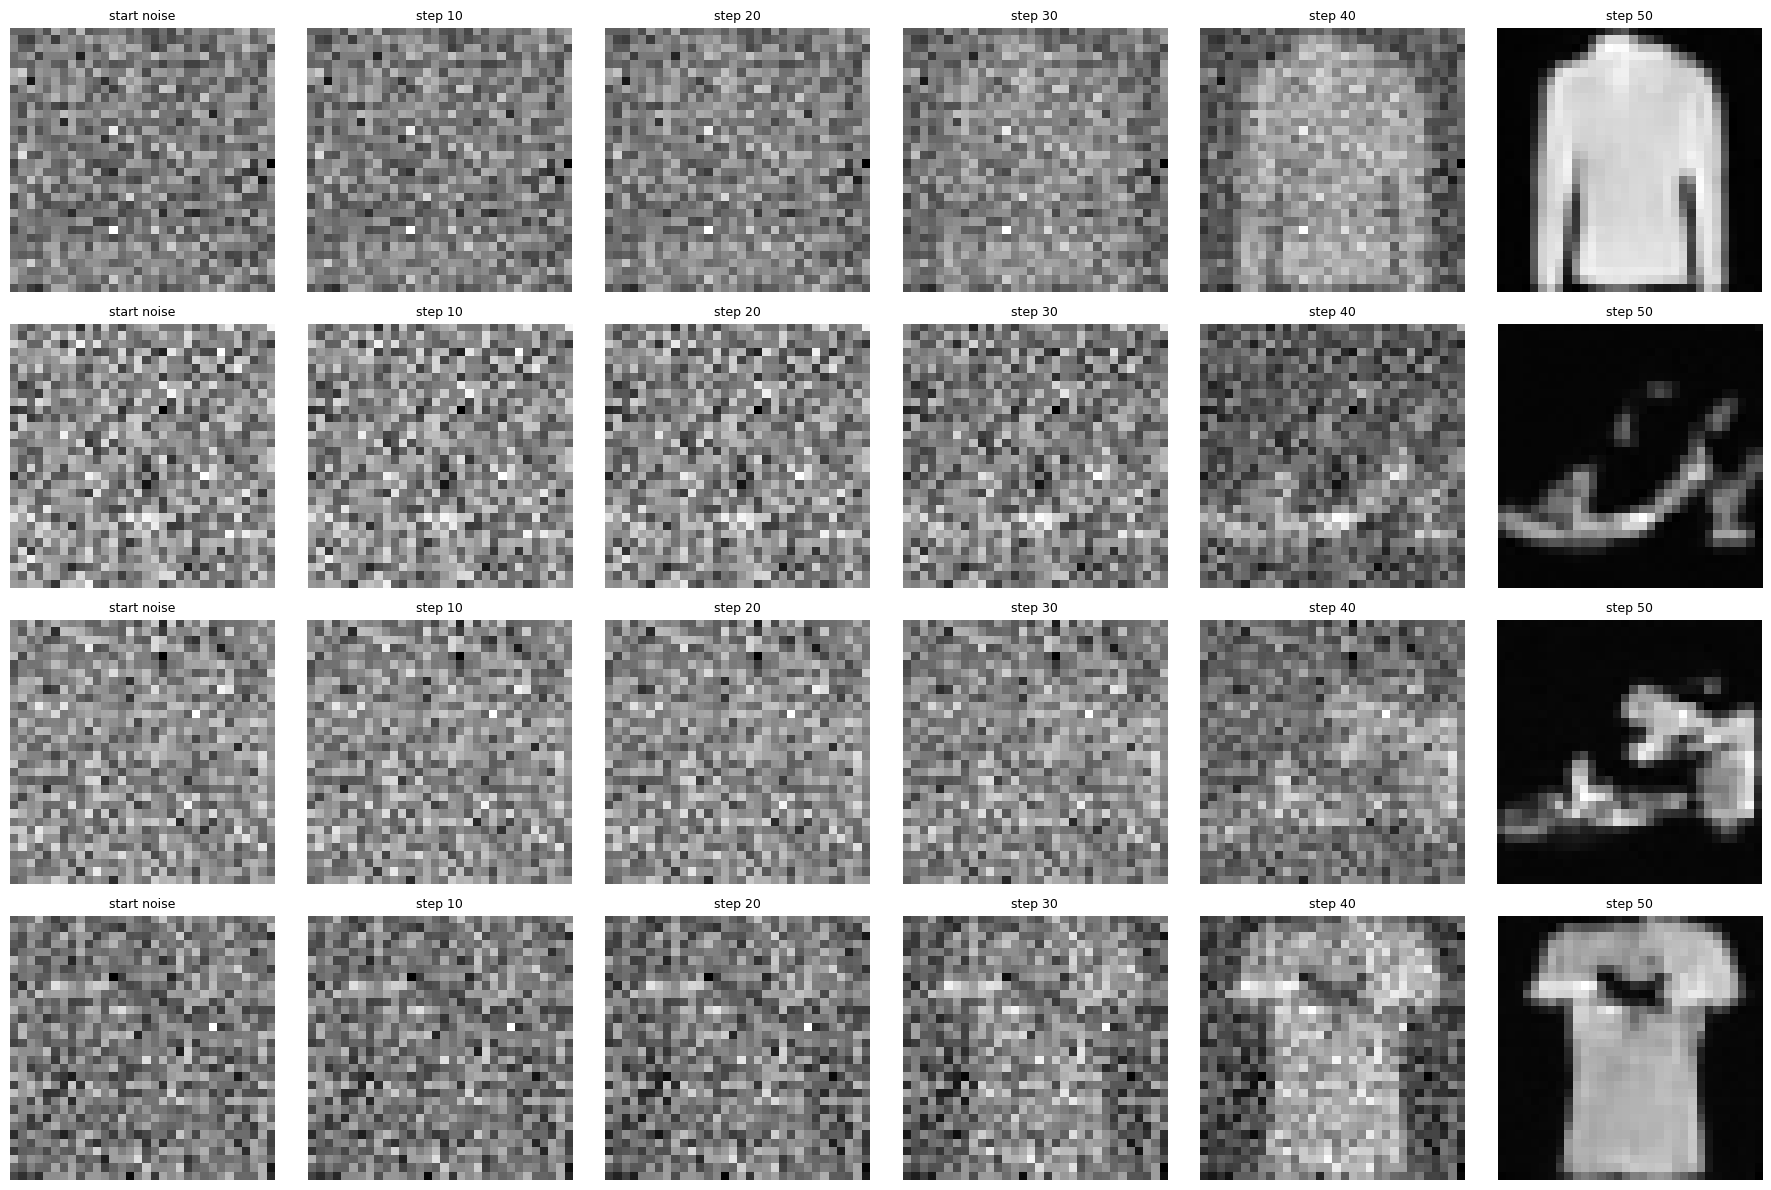

: 

In [ ]:
trajectory_noise = torch.randn(4, 1, args.image_size, args.image_size, device=args.device)
steps_to_show = [10, 20, 30, 40, 50]
images = trainer.generate_intermediate_samples(
    method="midpoint",
    n_samples=4,
    img_size=args.image_size,
    steps_to_show=steps_to_show,
    n_steps=50,
    noise=trajectory_noise,
    set_seed=True,
)
plot_intermediate_trajectory(images, steps_to_show, n_samples=4)


## Report question 9: sampling quality and efficiency

Use the figures above to discuss:
- how Euler changes with more steps
- how Midpoint compares against Euler at similar step counts or NFE budgets
- how Flow Matching compares with the DDPM baseline using the same starting noise
- the tradeoff between sample quality, runtime, and network-evaluation count
